<a href="https://colab.research.google.com/github/mc-castro/clinicaltrials-ia-thesis/blob/mc-castro%2Fdevelop/notebooks/06_analyze_ranking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Imports

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import userdata, drive
import os

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Analysis

In [ ]:
def analyze_ranking_results(file_path):
    df = pd.read_csv(file_path)

    # 1. Estatísticas Gerais
    total_processed = len(df)
    excluded_count = len(df[df['score'] == 0])
    high_priority = len(df[df['score'] >= 80])

    print(f"--- GLOBAL SUMMARY ---")
    print(f"Total Patient-Study Pairs: {total_processed}")
    print(f"Excluded by Protocol: {excluded_count} ({excluded_count/total_processed:.1%})")
    print(f"High Priority (Score >= 80): {high_priority} ({high_priority/total_processed:.1%})")
    print("-" * 30)

    # 2. Performance por Estudo (NCT_ID)
    # Agrupa para ver como a IA se comportou em cada protocolo
    study_summary = df.groupby('nct_id').agg({
        'subject_id': 'count',
        'score': ['mean', 'max'],
        'exclusion': 'sum',
        'risk': 'sum'
    }).reset_index()

    study_summary.columns = ['NCT_ID', 'Total_Patients', 'Avg_Score', 'Max_Score', 'Total_Exclusions', 'Total_At_Risk']
    print("\n--- PER STUDY ANALYSIS ---")
    print(study_summary)

    # 3. Visualização: Distribuição de Scores
    plt.figure(figsize=(10, 6))
    sns.histplot(df['score'], bins=10, kde=True, color='skyblue')
    plt.title('Distribution of Suitability Scores (All Studies)')
    plt.xlabel('Score (0-100)')
    plt.ylabel('Frequency')
    plt.axvline(x=70, color='red', linestyle='--', label='Minimum Threshold')
    plt.legend()
    plt.show()

    # 4. Visualização: Tipos de Evidências Encontradas
    evidence_types = df[['gold', 'diag', 'phys', 'symp']].sum()
    plt.figure(figsize=(8, 5))
    evidence_types.plot(kind='bar', color='teal')
    plt.title('Types of Evidence Extracted by LLM')
    plt.ylabel('Count of Patients')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return study_summary

In [ ]:
# # Configuração de estilo "Paper Ready"
# sns.set_theme(style="whitegrid", context="talk")

def plot_master_thesis_insights(file_path):
    df = pd.read_csv(file_path)

    # Criar uma figura com subplots
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    plt.subplots_adjust(hspace=0.5, wspace=0.3)

    # --- INSIGHT 1: Distribuição de Scores por Estudo (Violin Plot) ---
    # Corrigido: Atribuindo nct_id ao hue e removendo a legenda
    sns.violinplot(
        data=df, x='nct_id', y='score', ax=axes[0,0],
        inner="quart", hue='nct_id', palette="muted", legend=False
    )
    axes[0,0].set_title('A. Suitability Density per Clinical Trial', fontsize=18, fontweight='bold', pad=20)

    # Corrigido: Usando set_xticks antes de set_xticklabels para evitar o UserWarning
    axes[0,0].set_xticks(range(len(df['nct_id'].unique())))
    axes[0,0].set_xticklabels(df['nct_id'].unique(), rotation=45, ha='right', fontsize=12)
    axes[0,0].set_ylim(-10, 110)

    # --- INSIGHT 2: Pipeline de Qualificação (Stacked Bar) ---
    # Categorização clara para o "Funil de Seleção"
    qualified = len(df[(df['score'] > 0) & (df['risk'] == False)])
    at_risk = len(df[(df['score'] > 0) & (df['risk'] == True)])
    excluded = len(df[df['score'] == 0])

    categories = ['Qualified', 'At Risk', 'Excluded']
    values = [qualified, at_risk, excluded]
    colors = ['#2ecc71', '#f1c40f', '#e74c3c']

    axes[0,1].bar(categories, values, color=colors, edgecolor='black', alpha=0.8)
    axes[0,1].set_title('B. Patient Pipeline Classification', fontsize=18, fontweight='bold', pad=20)
    axes[0,1].set_ylabel('Number of Patients')
    for i, v in enumerate(values):
        axes[0,1].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

    # --- INSIGHT 3: Prevalência de Evidências (Bar Plot) ---
    evidence_cols = ['gold', 'diag', 'phys', 'symp']
    # Traduzindo colunas para nomes mais bonitos no gráfico
    display_names = {'gold': 'Procedures', 'diag': 'Diagnosis', 'phys': 'Physical Exam', 'symp': 'Symptoms'}

    evidence_pct = (df[evidence_cols].mean() * 100).rename(index=display_names)

    # Corrigido: Passando hue para o barplot
    sns.barplot(x=evidence_pct.index, y=evidence_pct.values, ax=axes[1,0], hue=evidence_pct.index, palette="viridis", legend=False)
    axes[1,0].set_title('C. Evidence Prevalence (%)', fontsize=18, fontweight='bold', pad=20)
    axes[1,0].set_ylim(0, 110)
    for i, v in enumerate(evidence_pct.values):
        axes[1,0].text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold')

    # --- INSIGHT 4: Comparação entre Grupos de Score (Boxplot) ---
    # Mostra se o risco de atrito está concentrado em scores altos ou baixos
    sns.boxplot(data=df, x='risk', y='score', hue='risk', ax=axes[1,1], palette="Set2", legend=False)
    axes[1,1].set_title('D. Attrition Risk vs. Eligibility Score', fontsize=18, fontweight='bold', pad=20)
    axes[1,1].set_xticklabels(['Low Risk', 'High Risk (At Risk)'])

    plt.suptitle(f"Clinical Trial Recruitment Analysis (N={len(df)})", fontsize=26, y=0.98, fontweight='bold')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

## Plots

--- GLOBAL SUMMARY ---
Total Patient-Study Pairs: 89
Excluded by Protocol: 34 (38.2%)
High Priority (Score >= 80): 21 (23.6%)
------------------------------

--- PER STUDY ANALYSIS ---
        NCT_ID  Total_Patients  Avg_Score  Max_Score  Total_Exclusions  \
0  NCT03319472              89  36.044944        100                33   

   Total_At_Risk  
0             21  


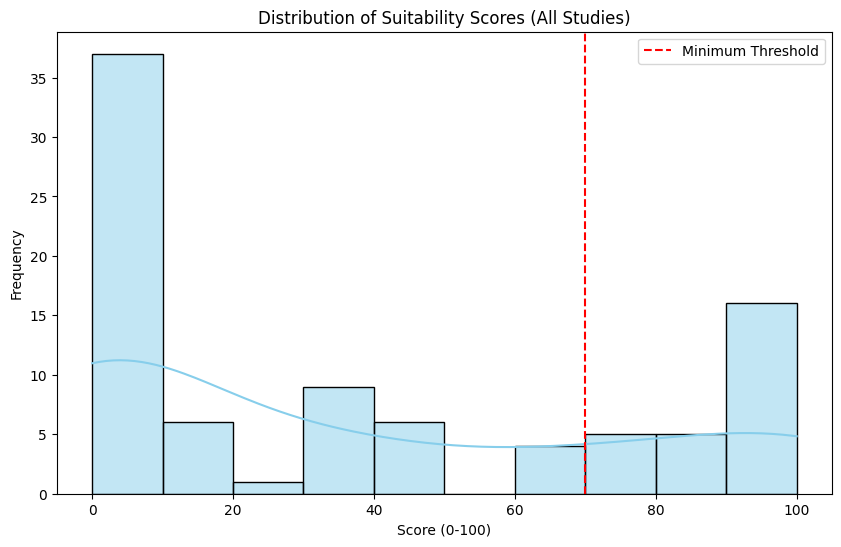

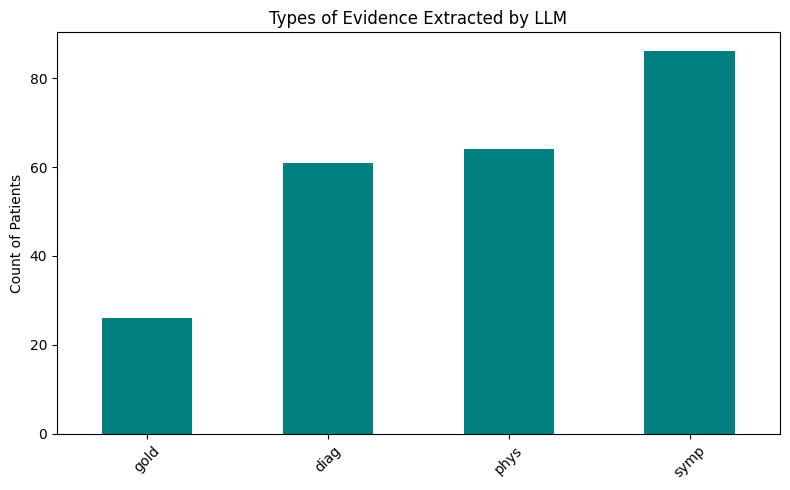

In [ ]:
path_ranking = "/content/drive/My Drive/Mestrado/Dissertação/mimic-iv-ext-cardiac-disease/processed/ranking_incremental_v1.csv"

stats_df = analyze_ranking_results(path_ranking)

/tmp/ipython-input-3664910957.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,1].set_xticklabels(['Low Risk', 'High Risk (At Risk)'])


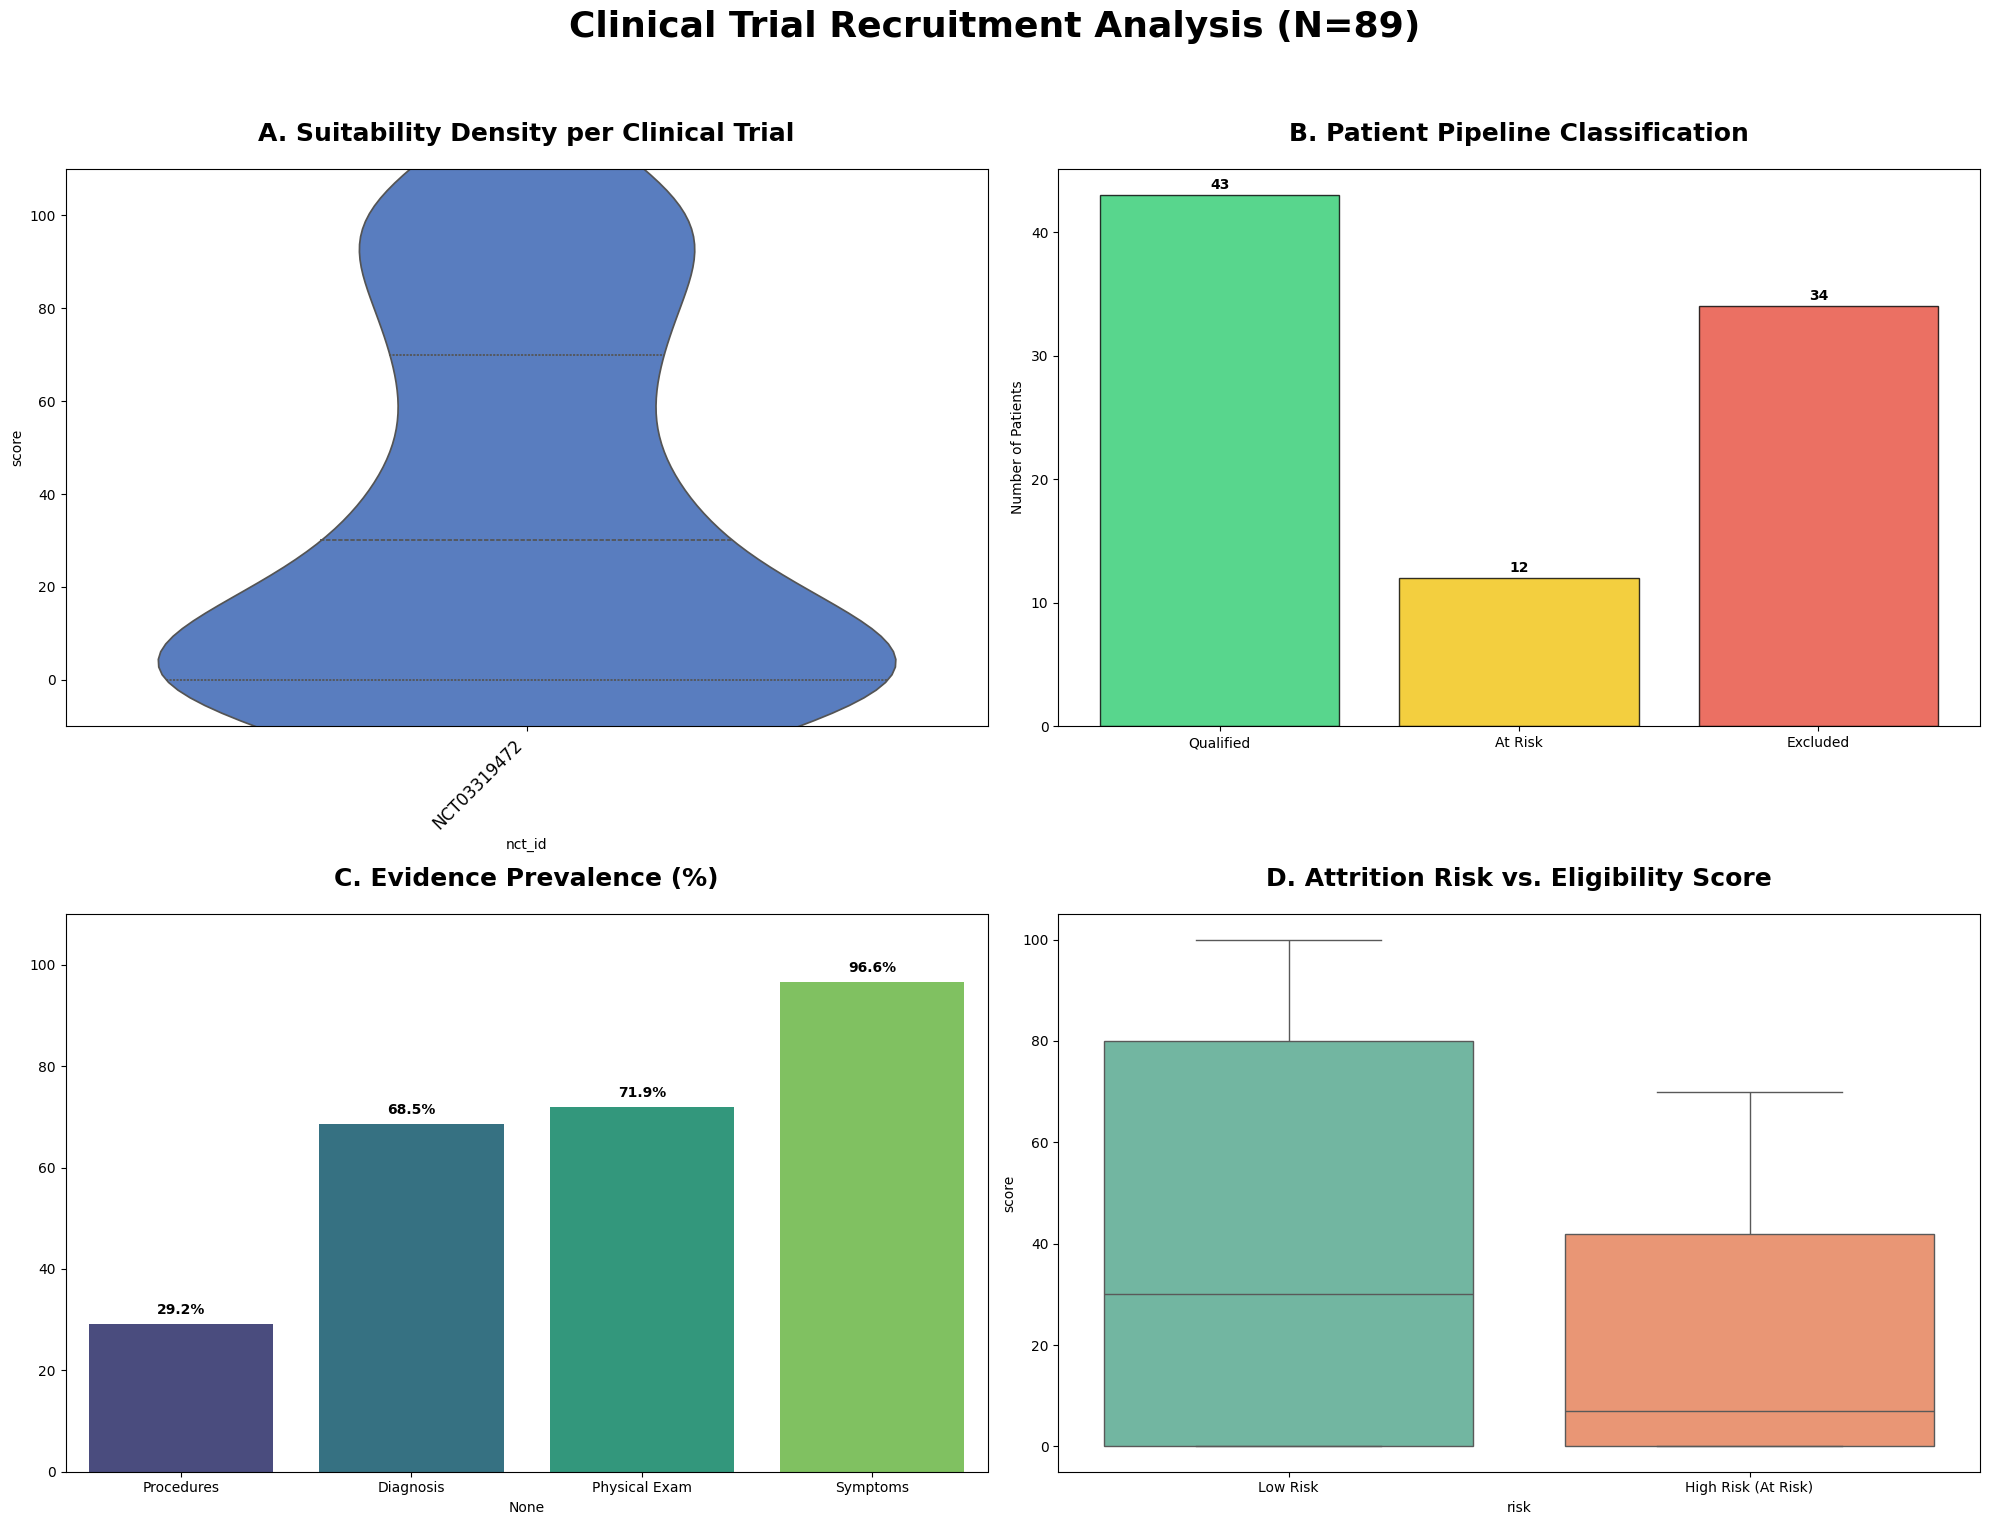

In [ ]:
plot_master_thesis_insights(path_ranking)